      Característica  Información Mutua
2  petal length (cm)           0.992573
3   petal width (cm)           0.985643
0  sepal length (cm)           0.511365
1   sepal width (cm)           0.299424


/tmp/ipykernel_98431/1940622353.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='Información Mutua', y='Característica', palette="viridis")


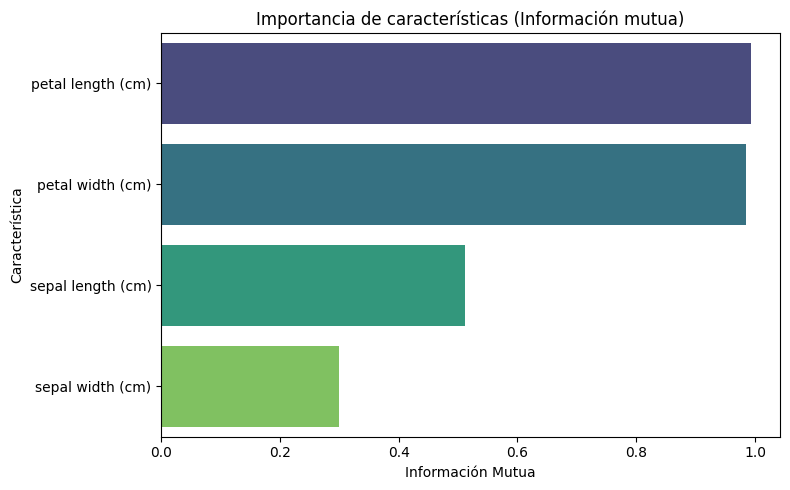

In [3]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset de Iris
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

# Calcular la información mutua
mi_scores = mutual_info_classif(X, y, random_state=42)

# Convertir a DataFrame
mi_df = pd.DataFrame({
    'Característica': X.columns,
    'Información Mutua': mi_scores
}).sort_values(by='Información Mutua', ascending=False)

# Mostrar resultados
print(mi_df)

# Gráfico
plt.figure(figsize=(8, 5))
sns.barplot(data=mi_df, x='Información Mutua', y='Característica', palette="viridis")
plt.title('Importancia de características (Información mutua)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_98431/3751189322.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x='Correlación', y='Característica', order=corr_df['Característica'], palette='viridis', ax=axes[0])
/tmp/ipykernel_98431/3751189322.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi2_df, x='Chi2', y='Característica', order=chi2_df['Característica'], palette='magma', ax=axes[1])


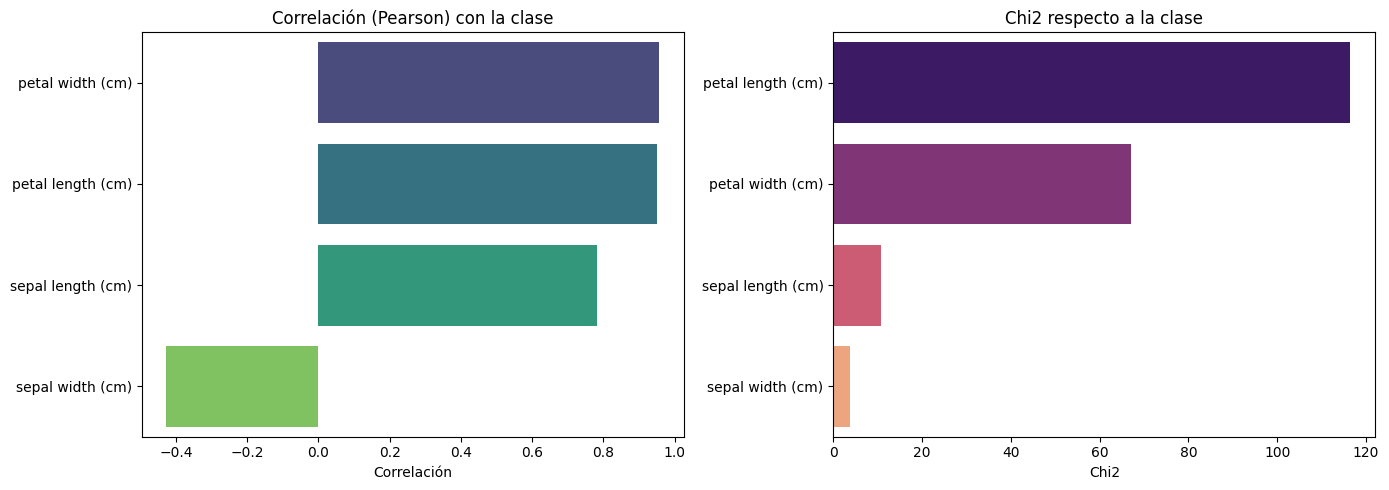

In [2]:
from sklearn.feature_selection import chi2

# Correlación (Pearson) entre cada característica y la clase
corr_series = X.corrwith(y)
corr_df = pd.DataFrame({
    'Característica': corr_series.index,
    'Correlación': corr_series.values
}).assign(abs_corr=lambda df: df['Correlación'].abs()).sort_values('abs_corr', ascending=False)

# Chi2 (estadístico y p-valor)
chi2_stats, chi2_p = chi2(X, y)
chi2_df = pd.DataFrame({
    'Característica': X.columns,
    'Chi2': chi2_stats,
    'p_value': chi2_p
}).sort_values('Chi2', ascending=False)

# Plots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=corr_df, x='Correlación', y='Característica', order=corr_df['Característica'], palette='viridis', ax=axes[0])
axes[0].set_title('Correlación (Pearson) con la clase')
axes[0].set_xlabel('Correlación')
axes[0].set_ylabel('')

sns.barplot(data=chi2_df, x='Chi2', y='Característica', order=chi2_df['Característica'], palette='magma', ax=axes[1])
axes[1].set_title('Chi2 respecto a la clase')
axes[1].set_xlabel('Chi2')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()